<a href="https://colab.research.google.com/github/JordanBaker78/Data201_JordanBaker/blob/main/Data201_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 2: Title

## DATA 201 Spring 2026

## Jordan Baker

## Introduction

### Dataset:
https://raw.githubusercontent.com/JordanBaker78/Data201_JordanBaker/refs/heads/main/Project%202/job_salary_prediction_dataset(in).csv

Dataset Description: This dataset contains 250,000 job records designed for salary prediction, data analysis, and machine learning projects. It includes information about job titles, experience level, educational background, skills, industry type, company size, and work location.


It is unknown where the data was collected from or if the data is real-world data. The dataset is very good for an experimental project, but documentation of the Metadata is poor if not non-existent, so real-world application is limited unless further information on the dataset is produced.


Dataset Overview: The dataset has 250,000 rows and 10 columns. The columns are 'Job_title', 'Experience_years', 'Education_level', 'Skills_count', 'Industry', 'Company_size', 'Location', 'Remote_work', 'Certifications', and 'Salary'. There are 6 categorical columns and 4 numerical columns. Each row represents a different individual worker in an industry. There are ten industries from locations across the world.

## Data Analysis and Modeling:

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data201_JordanBaker/refs/heads/main/Project%202/job_salary_prediction_dataset(in).csv')
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


###a. Data Exploration and Visualization:

###a.1 Visulization 1 : Boxplot and Violin Plot

In [3]:
mean_salary = df.groupby('industry')['salary'].mean()
mean_salary

,salary
industry,
Consulting,145451.638293
Education,145993.564547
Finance,145801.639468
Government,145613.869242
Healthcare,145759.995702
Manufacturing,145530.603301
Media,145891.271071
Retail,145399.699408
Technology,145863.808377


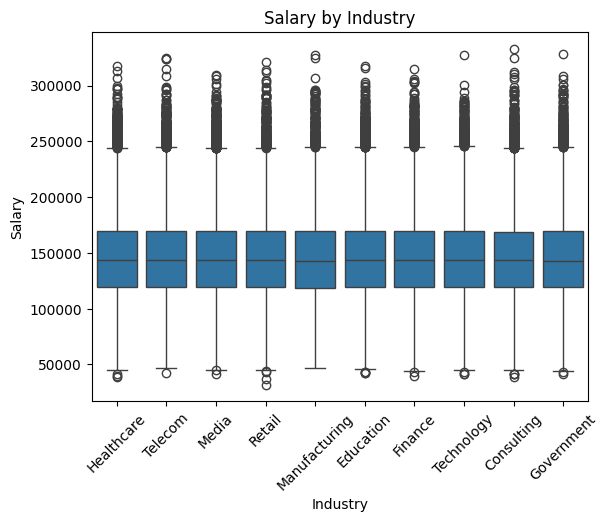

In [4]:
sns.boxplot(data=df, x="industry", y="salary")
plt.title('Salary by Industry')
plt.xlabel('Industry')
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.show()


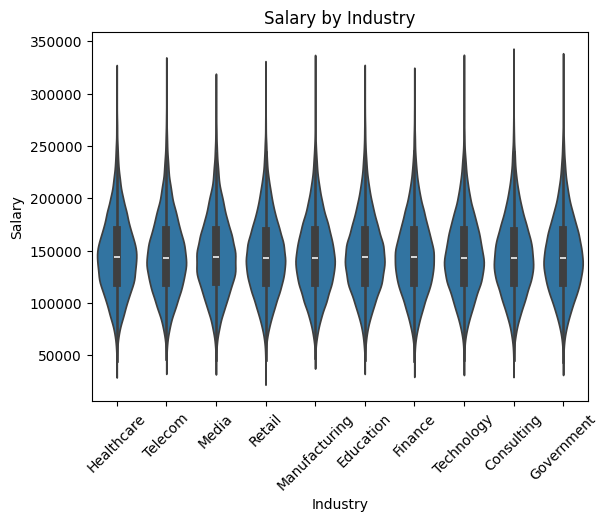

In [5]:
sns.violinplot(data=df, x="industry", y="salary")
plt.title('Salary by Industry')
plt.xlabel('Industry')
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.show()

These two plots show that the distribution for the relationship between industry and salary is very similar across all industries. The mean salary for each industry is very close; all the industries have a mean salary around 145k, no less than 145.4k, and no more than 146k. The spread of the distributions vary slighlty but is still remarkably similar.

###a.2 Visulization 2: Replot

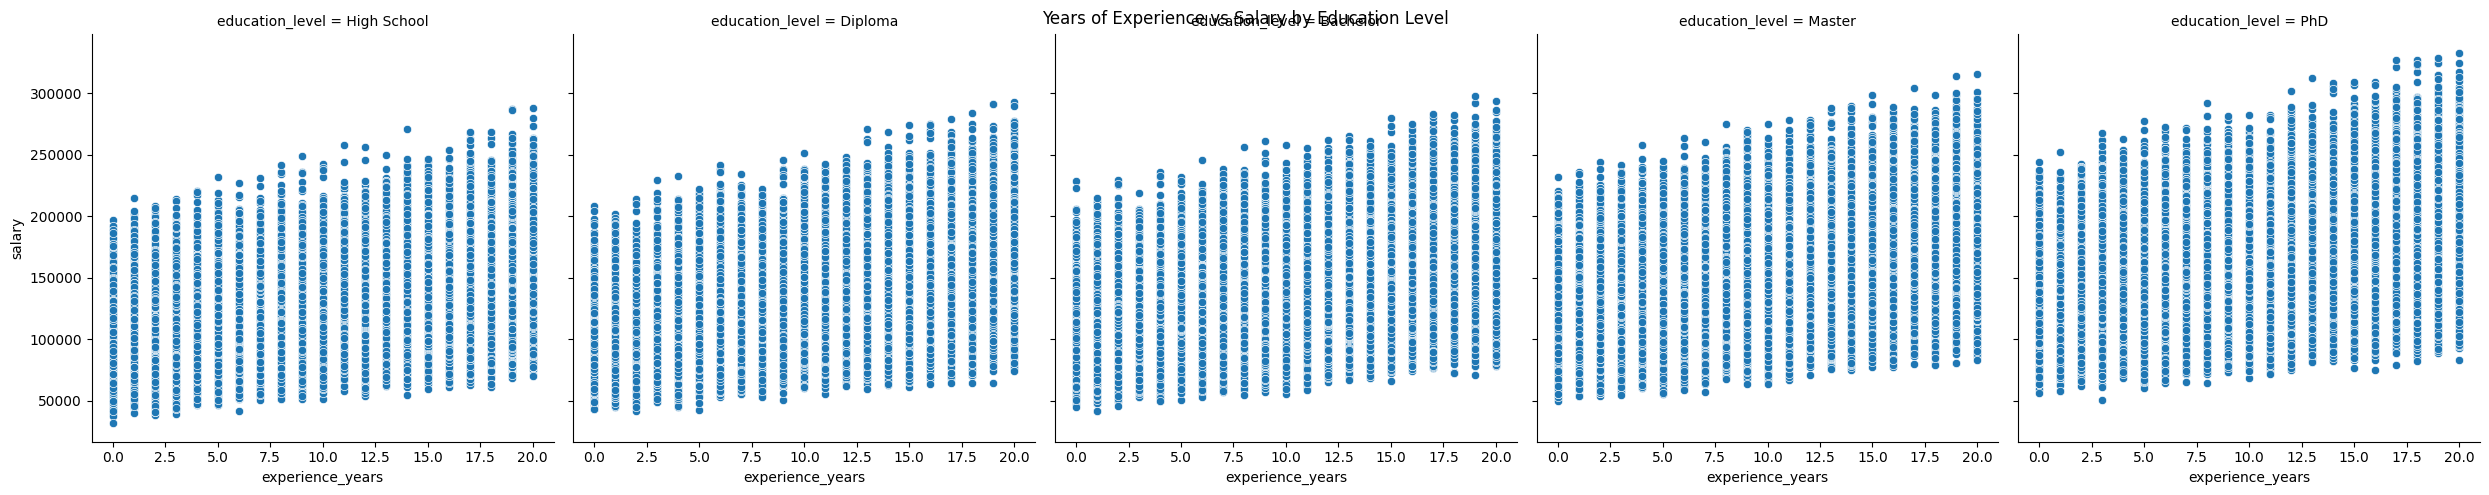

In [6]:
education_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
sns.relplot(data=df, x="experience_years", y="salary", col="education_level", col_order=education_order)
plt.suptitle("Years of Experience vs Salary by Education Level")
plt.show()

This is an interesting set of plots that displays Salary vs Years of experience, separated by the Education level. While the spread of each of the plots is similar, we can see that the average salary slightly increases with each higher level of education, with PhD reaching the highest salaries over 300K. We can also see that, on average, the salary increases with more years of experience, no matter what the level of education is.

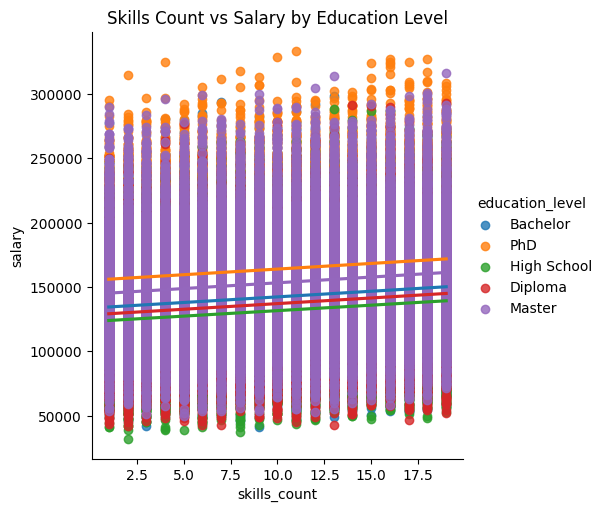

In [7]:
sns.lmplot(data=df, x='skills_count', y='salary', hue='education_level')
plt.title("Skills Count vs Salary by Education Level")
plt.show()

This plot is another way of visualizing the previous set of graphs, using skill count as the independent variable instead of years of experience. Despite the change in independent variables, the analysis remains similar. Both visualizations show that there is a positive relationship (albeit a very minor one) between both skill count and salary and years of experience and salary, as well as education level.

###b. Train/Test Split

In [19]:
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

x1 = df[["skills_count"]]
y = df["salary"]
x_train, x_test, y_train, y_test = train_test_split(x1, y, test_size=0.2)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


In [20]:
# Compute RMSE on test set
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE on test set: {rmse:.2f}")

# Compute R² on test set
r2 = r2_score(y_test, y_pred)
print(f"R-squared on test set: {r2:.2f}")

RMSE on test set: 37092.98
R-squared on test set: 0.02


In [16]:
x2 = df[["experience_years"]]
y = df["salary"]
x_train, x_test, y_train, y_test = train_test_split(x2, y, test_size=0.2)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


I chose an 80/20 split for this test becuase it is the most standard ratio. This dataset is fairly large, so I wouldn't use a smaller ratio, like 70/30 or 60/40, but it isn't a dataset with millions of records so I also wouldn't use a larger ratio like 90/10 or 95/5.

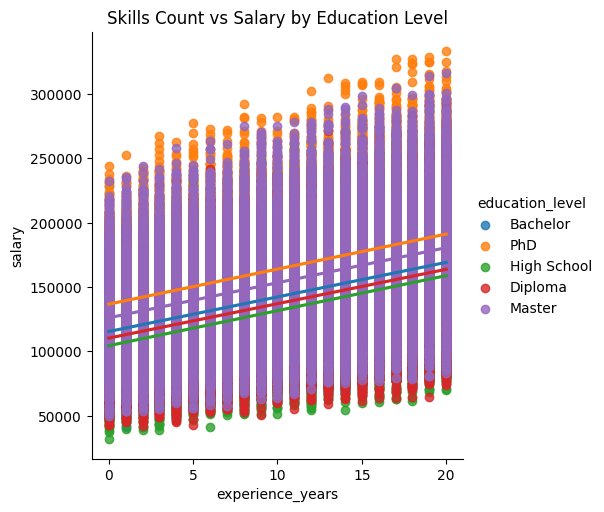

In [10]:
sns.lmplot(data=df, x='experience_years', y='salary', hue='education_level')
plt.title("Skills Count vs Salary by Education Level")
plt.show()

###c. Linear Regression Model

In [11]:
model = smf.ols("salary ~ skills_count", data = df) .fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4118.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        16:56:25   Log-Likelihood:            -2.9851e+06
No. Observations:              250000   AIC:                         5.970e+06
Df Residuals:                  249998   BIC:                         5.970e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      1.37e+05    154.404    887.468      0.000    1.37e+05    1.37e+05
skills_count   869.0949     13.543     64.172      0.000     842.550     895.639
==============================================================================
Omnibus:                     5725.215   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6131.324
Skew:                           0.376   Prob(JB):                         0.00
Kurtosis:                       3.149   Cond. No.                         23.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

For this first regression model, I used salary as the dependent variable, and  and skills count for the independent variable, since those are the variables I used in the first regression plot. The regression summary shows three important statistics, the Rsquared value, coefficent and p value, that we can use to understand the corelation between salary and skills count.

###d. Improved Model

In [12]:
model = smf.ols("salary ~ skills_count + experience_years + education_level", data = df) .fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                 1.821e+04
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        16:56:26   Log-Likelihood:            -2.9418e+06
No. Observations:              250000   AIC:                         5.884e+06
Df Residuals:                  249993   BIC:                         5.884e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                       1.066e+05    207.737    513.042      0.000    1.06e+05    1.07e+05
education_level[T.Diploma]     -5232.2082    197.641    -26.473      0.000   -5619.579   -4844.837
education_level[T.High School] -1.066e+04    197.355    -54.031      0.000    -1.1e+04   -1.03e+04
education_level[T.Master]       1.104e+04    197.074     56.037      0.000    1.07e+04    1.14e+04
education_level[T.PhD]          2.164e+04    197.561    109.530      0.000    2.13e+04     2.2e+04
skills_count                     872.7468     11.391     76.618      0.000     850.421     895.073
experience_years                2703.7342     10.298    262.541      0.000    2683.550    2723.919
==============================================================================
Omnibus:                     2426.296   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2574.328
Skew:                           0.222   Prob(JB):                         0.00
Kurtosis:                       3.225   Cond. No.                         84.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In this model, I added the variable education level for the same reasons I used the other varibles. This model shows the numbers behind the two visulizations I already created and brings them together in one model. This model is better than the first because it brings in to account three important factors in the dataset that determine salary.



###e. Comparing and Interpreting Models

In the first model, the coefficient on skills count is 869.0949, meaning every additional skill is associated with a 869.0949 change in salary, assuming bedrooms is held constant. Based on the reported value of P>|t| = 0.00, we can determine that the variable size is statistically significant.
The R² value of 0.016 means that 16% of the variance in salary can be explained by the number of skills. So, despite the clear evidence from the visualization that there is somewhat of a relationship, the model declares that only a small part of the skills count data can be used to predict salary.


For the second model, the coefficient on experience years is 2703.7342, meaning every additional year of experience is associated with a 2703.7342 increase in salary. As we saw from the previous visualizations, this increase in salary based on years of experience (and number of skills) is consistent with higher levels of education. It is also interesting that the standard error, while not the same, is very similar for each level of education.
In the second model, the R² value of 0.304 means that about 30%  of the variance in salary can be explained by all the independent variables used in the model. While this value is significantly greater than the value we got in the first model, it is still not as high as I'd expect when using three dependent variables that all appear to have a positive relationship with salary. The second model is still better than the first, simply based on the R² value, but I would think that there are better models that would be able to more accurately predict salary based on the variables used in this model.


###f. Perdictions

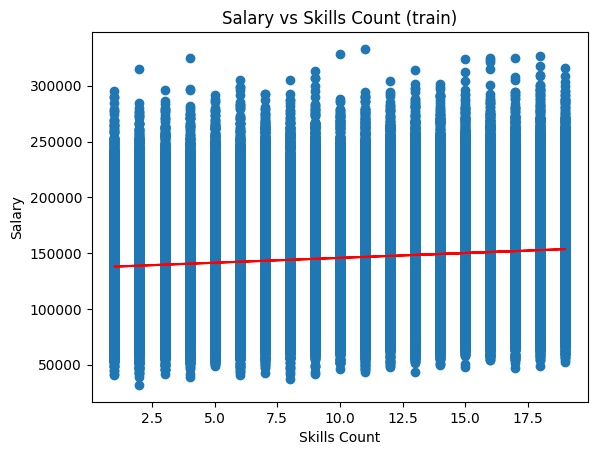

In [23]:
plt.scatter(x_train, y_train)
plt.plot(x_train, model.predict(x_train), color='red')
plt.xlabel('Skills Count')
plt.ylabel('Salary')
plt.title('Salary vs Skills Count (train)')
plt.show()

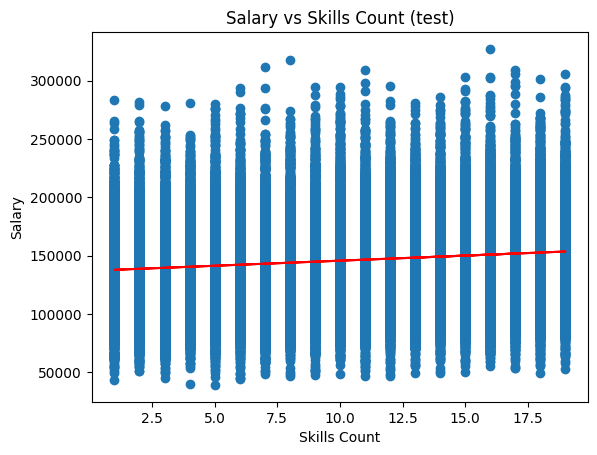

In [24]:
plt.scatter(x_test, y_test)
plt.plot(x_train, model.predict(x_train), color='red')
plt.xlabel('Skills Count')
plt.ylabel('Salary')
plt.title('Salary vs Skills Count (test)')
plt.show()

In [25]:
y_pred = model.predict(np.array([[10]]))
print(f"Predicted salary for 10 skills: ${y_pred[0]:.2f}")

Predicted salary for 10 skills: $145759.06


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
y_pred = model.predict(np.array([[20]]))
print(f"Predicted salary for 20 skills: ${y_pred[0]:.2f}")

Predicted salary for 20 skills: $154470.90


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [27]:
y_pred = model.predict(np.array([[30]]))
print(f"Predicted salary for 30 skills: ${y_pred[0]:.2f}")

Predicted salary for 30 skills: $163182.74


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


This model shows the predicted salary for 10, 20, and 30 skills based on the data. For 10 skills, the predicted salary is 145,759 dollars, for 20 skills, 154,470 dollars, and for 30 skills, 163,182 dollars. This looks accurate based on the regression line that we see from the plot, and even though 20 and 30 skills are not in this dataset, we can infer what the salary may be from the model. However, we can also see from the plot that there is an extremely wide range of possible salaries for each number of skills. We also know from the previous models that years of experience and education level have an effect on the predicted salary, and the number of skills can only accurately predict a small portion of the data.

###Conclusion

One conclusion I have after working on this project is that, according to this data, there are many factors that affect an individual's salary. I am surprised that the variables that I focused on in this project didn't have a more significant impact on the ability to predict the salary, whether it was individually or collectively. The biggest takeaway may be that there is more work to be done to see which of these variables actually has the biggest impact on salary. There didn't seem to be much variation in salary by industry, and there was a steady increase in salaries for increases in both the years of experience and level of education. All that being said, because the source of the dataset is unknown, the verifiability of the data is also unknown; we can't really make any solid 'real-world' conclusions based on the tests done in this project.